# 08 — MD extensions core: experimentalist-safe trajectory triage

This notebook extends the restart-safe threaded-complex MD notebook without launching new simulations. It is intentionally conservative: the goal is to detect obvious interface failures and summarize persistent geometric contacts, not to claim binding affinity or mechanistic proof.

Run this after `08_md_simulation_colab_CLEAN_restart_safe_THREADED_COMPLEX_v2.ipynb` has produced trajectories in `md_simulations_threaded_complexes`.

## Cell 0 — Install/import, mount Drive, and locate completed MD systems

In [1]:
# ============================================================
# Cell 0 — Setup and completed-system discovery
# ============================================================

import sys, subprocess, importlib.util

# Keep this cell lightweight. It installs only analysis dependencies if needed.
for pkg in ["mdtraj"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from collections import defaultdict, Counter
import json, math, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mdtraj as md

# -----------------------------
# Project paths — match parent notebook defaults.
# -----------------------------
PROJECT_DIR = Path("/content/drive/Othercomputers/My Mac/pdl1-mini-binder-design")
RESULTS_DIR = PROJECT_DIR / "data" / "results"
MD_OUTPUT_DIR = RESULTS_DIR / "md_simulations_threaded_complexes"
MANIFEST_PATH = MD_OUTPUT_DIR / "md_manifest.csv"
SUMMARY_PATH = MD_OUTPUT_DIR / "md_simulation_summary.csv"
CORE_SUMMARY_PATH = MD_OUTPUT_DIR / "md_extensions_core_summary.csv"

FORCE_CORE_ANALYSIS = False
CONTACT_CUTOFF_NM = 0.45      # 4.5 Å residue-level contact cutoff
HBOND_MIN_OCCUPANCY = 0.10    # report H-bonds present in >=10% of frames
TOP_N_CONTACTS = 30

print("PROJECT_DIR:", PROJECT_DIR, PROJECT_DIR.exists())
print("MD_OUTPUT_DIR:", MD_OUTPUT_DIR, MD_OUTPUT_DIR.exists())
print("MANIFEST_PATH:", MANIFEST_PATH, MANIFEST_PATH.exists())

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Could not find MD manifest: {MANIFEST_PATH}\n"
        "Run the parent restart-safe MD notebook first, or update PROJECT_DIR / MD_OUTPUT_DIR."
    )

def _clean_path(x):
    if x is None:
        return None
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return None
    return Path(s)

manifest_df = pd.read_csv(MANIFEST_PATH)
prepared_systems = []
for _, row in manifest_df.iterrows():
    s = row.to_dict()
    # Convert known path-like values to strings after resolving; keep JSON-serializable.
    for key in ["drive_dir", "traj_dcd", "equilibrated_pdb", "final_pdb", "input_pdb"]:
        p = _clean_path(s.get(key))
        s[key] = str(p) if p is not None else ""
    prepared_systems.append(s)

# Only analyze systems with existing trajectory + topology.
completed_systems = []
for s in prepared_systems:
    traj = _clean_path(s.get("traj_dcd"))
    top = _clean_path(s.get("equilibrated_pdb"))
    if traj and top and traj.exists() and top.exists():
        completed_systems.append(s)
    else:
        print("Skipping incomplete system:", s.get("design_name"), "traj:", traj, "top:", top)

print(f"Completed systems available for core extension analysis: {len(completed_systems)}")
for s in completed_systems:
    print(" -", s.get("design_name"), "| condition:", s.get("condition_id"), "| target:", s.get("target_chain"), "| binder:", s.get("binder_chain"))


Mounted at /content/drive
PROJECT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design True
MD_OUTPUT_DIR: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes True
MANIFEST_PATH: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_manifest.csv True
Completed systems available for core extension analysis: 3
 - len70_clusterA_noise05__design_19_0_rank0 | condition: len70_clusterA_noise05 | target: A | binder: B
 - len70_distributed_noise0__design_17_0_rank1 | condition: len70_distributed_noise0 | target: A | binder: B
 - len70_clusterB_noise0__design_19_0_rank1 | condition: len70_clusterB_noise0 | target: A | binder: B


## Cell 1 — Shared helper functions

These helpers deliberately reuse `target_chain` and `binder_chain` from the parent manifest instead of re-inferring chain roles from sequence length.

In [2]:
# ============================================================
# Cell 1 — Core helper functions
# ============================================================

AA_CLASSES = {
    "hydrophobic": {"ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP", "PRO"},
    "aromatic": {"PHE", "TYR", "TRP", "HIS"},
    "positive": {"LYS", "ARG", "HIS"},
    "negative": {"ASP", "GLU"},
    "polar": {"SER", "THR", "ASN", "GLN", "TYR", "CYS", "HIS"},
}

CHARGED_ATOMS = {
    "ASP": ["OD1", "OD2"],
    "GLU": ["OE1", "OE2"],
    "LYS": ["NZ"],
    "ARG": ["NH1", "NH2", "NE"],
    "HIS": ["ND1", "NE2"],  # approximate; protonation state not resolved here
}

AROMATIC_RING_ATOMS = {
    "PHE": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
    "TYR": ["CG", "CD1", "CD2", "CE1", "CE2", "CZ"],
    "TRP": ["CD2", "CE2", "CE3", "CZ2", "CZ3", "CH2"],
    "HIS": ["CG", "ND1", "CD2", "CE1", "NE2"],
}


def residue_label(residue):
    resseq = residue.resSeq if residue.resSeq is not None else residue.index + 1
    return f"{residue.name}{resseq}"


def get_chain_index_from_chain_id(topology, chain_id):
    chain_id = str(chain_id).strip()
    for chain in topology.chains:
        if str(chain.chain_id).strip() == chain_id:
            return chain.index
    available = [(c.index, c.chain_id, sum(1 for _ in c.residues)) for c in topology.chains]
    raise ValueError(f"Chain ID {chain_id!r} not found. Available chains: {available}")


def infer_frame_interval_ps(traj, system_info):
    if traj.n_frames > 1 and traj.time is not None:
        dt = float(np.median(np.diff(traj.time)))
        if np.isfinite(dt) and dt > 0:
            return dt
    production_ns = float(system_info.get("production_ns", 0) or 0)
    if production_ns > 0 and traj.n_frames > 1:
        return production_ns * 1000.0 / (traj.n_frames - 1)
    return np.nan


def load_protein_trajectory(system_info):
    traj_path = Path(system_info["traj_dcd"])
    top_path = Path(system_info["equilibrated_pdb"])
    traj = md.load(str(traj_path), top=str(top_path))
    protein_atoms = traj.topology.select("protein")
    traj = traj.atom_slice(protein_atoms)
    target_chain_id = str(system_info.get("target_chain", "A")).strip()
    binder_chain_id = str(system_info.get("binder_chain", "B")).strip()
    target_chain_idx = get_chain_index_from_chain_id(traj.topology, target_chain_id)
    binder_chain_idx = get_chain_index_from_chain_id(traj.topology, binder_chain_id)
    return traj, target_chain_idx, binder_chain_idx


def classify_pair(res1_name, res2_name):
    r1, r2 = res1_name.upper(), res2_name.upper()
    if r1 in AA_CLASSES["aromatic"] and r2 in AA_CLASSES["aromatic"]:
        return "candidate_aromatic"
    if (r1 in AA_CLASSES["positive"] and r2 in AA_CLASSES["negative"]) or (r1 in AA_CLASSES["negative"] and r2 in AA_CLASSES["positive"]):
        return "candidate_salt_bridge"
    if (r1 in AA_CLASSES["aromatic"] and r2 in AA_CLASSES["positive"]) or (r2 in AA_CLASSES["aromatic"] and r1 in AA_CLASSES["positive"]):
        return "candidate_cation_pi"
    if r1 in AA_CLASSES["hydrophobic"] and r2 in AA_CLASSES["hydrophobic"]:
        return "candidate_hydrophobic"
    if r1 in AA_CLASSES["polar"] or r2 in AA_CLASSES["polar"]:
        return "candidate_polar"
    return "other_contact"


def contiguous_true_runs(bool_array):
    runs, current = [], 0
    for val in np.asarray(bool_array, dtype=bool):
        if val:
            current += 1
        elif current:
            runs.append(current)
            current = 0
    if current:
        runs.append(current)
    return runs


def transition_count_on(bool_array):
    arr = np.asarray(bool_array, dtype=bool)
    if len(arr) == 0:
        return 0
    return int((1 if arr[0] else 0) + np.sum((~arr[:-1]) & arr[1:]))


def system_outdir(system_info):
    out = Path(system_info["drive_dir"])
    out.mkdir(parents=True, exist_ok=True)
    return out


## Cell 2 — Interface RMSD and center-of-mass drift

This is the main sanity check: after aligning every frame on PD-L1/target Cα atoms, does the binder remain positioned near the same interface?


=== Interface RMSD / drift: len70_clusterA_noise05__design_19_0_rank0 ===


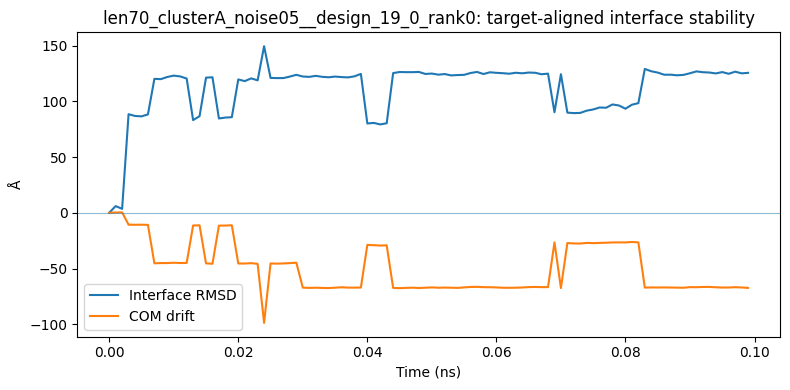


=== Interface RMSD / drift: len70_distributed_noise0__design_17_0_rank1 ===


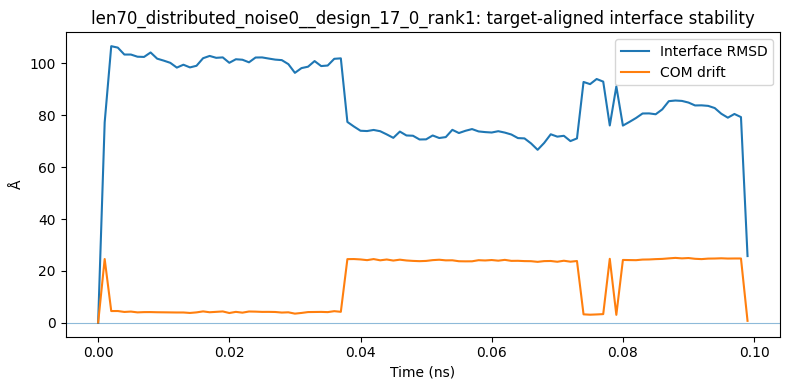


=== Interface RMSD / drift: len70_clusterB_noise0__design_19_0_rank1 ===


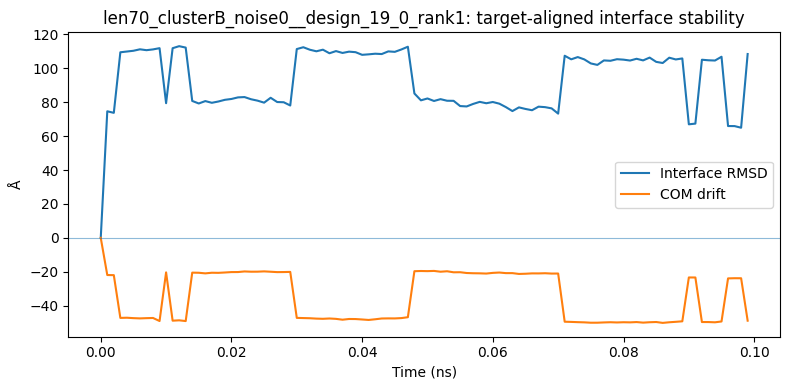

,design_name,interface_rmsd_mean_A,interface_rmsd_final_A,com_drift_final_A,com_drift_max_abs_A
0,len70_clusterA_noise05__design_19_0_rank0,111.291985,125.490509,-67.391006,98.773964
1,len70_distributed_noise0__design_17_0_rank1,84.462830,25.743582,0.791687,25.036186
2,len70_clusterB_noise0__design_19_0_rank1,92.807022,108.458824,-48.858147,50.153725


In [3]:
# ============================================================
# Cell 2 — Interface RMSD and COM drift
# ============================================================

def compute_interface_rmsd_and_drift(system_info, force=FORCE_CORE_ANALYSIS):
    out_dir = system_outdir(system_info)
    out_csv = out_dir / "core_interface_rmsd_drift.csv"
    out_json = out_dir / "core_interface_rmsd_drift_summary.json"
    out_png = out_dir / "core_interface_rmsd_drift.png"

    if out_json.exists() and out_csv.exists() and not force:
        with open(out_json) as f:
            return json.load(f)

    design = system_info.get("design_name")
    print(f"\n=== Interface RMSD / drift: {design} ===")
    traj, target_chain_idx, binder_chain_idx = load_protein_trajectory(system_info)
    frame_interval_ps = infer_frame_interval_ps(traj, system_info)
    time_ns = np.arange(traj.n_frames) * frame_interval_ps / 1000.0 if np.isfinite(frame_interval_ps) else np.arange(traj.n_frames)

    target_ca = traj.topology.select(f"chainid {target_chain_idx} and name CA")
    binder_ca = traj.topology.select(f"chainid {binder_chain_idx} and name CA")
    target_atoms = traj.topology.select(f"chainid {target_chain_idx} and not element H")
    binder_atoms = traj.topology.select(f"chainid {binder_chain_idx} and not element H")

    if len(target_ca) == 0 or len(binder_ca) == 0:
        raise ValueError(f"Missing target/binder CA atoms for {design}")

    aligned = traj.superpose(traj, frame=0, atom_indices=target_ca, ref_atom_indices=target_ca)

    # Binder positional RMSD after target alignment.
    binder_xyz = aligned.xyz[:, binder_ca, :]
    ref_xyz = aligned.xyz[0, binder_ca, :][None, :, :]
    interface_rmsd_A = np.sqrt(np.mean(np.sum((binder_xyz - ref_xyz) ** 2, axis=2), axis=1)) * 10.0

    # Binder-target COM distance after target alignment.
    target_com = aligned.xyz[:, target_atoms, :].mean(axis=1)
    binder_com = aligned.xyz[:, binder_atoms, :].mean(axis=1)
    com_distance_A = np.linalg.norm(binder_com - target_com, axis=1) * 10.0
    com_drift_A = com_distance_A - com_distance_A[0]

    df = pd.DataFrame({
        "time_ns": time_ns,
        "interface_rmsd_A": interface_rmsd_A,
        "binder_target_com_distance_A": com_distance_A,
        "binder_target_com_drift_A": com_drift_A,
    })
    df.to_csv(out_csv, index=False)

    summary = {
        "design_name": design,
        "n_frames": int(traj.n_frames),
        "frame_interval_ps": float(frame_interval_ps),
        "interface_rmsd_mean_A": float(np.mean(interface_rmsd_A)),
        "interface_rmsd_final_A": float(interface_rmsd_A[-1]),
        "interface_rmsd_max_A": float(np.max(interface_rmsd_A)),
        "com_distance_initial_A": float(com_distance_A[0]),
        "com_distance_final_A": float(com_distance_A[-1]),
        "com_drift_final_A": float(com_drift_A[-1]),
        "com_drift_max_abs_A": float(np.max(np.abs(com_drift_A))),
        "csv": str(out_csv),
        "plot": str(out_png),
    }
    with open(out_json, "w") as f:
        json.dump(summary, f, indent=2)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time_ns, interface_rmsd_A, label="Interface RMSD")
    ax.plot(time_ns, com_drift_A, label="COM drift")
    ax.axhline(0, lw=0.8, alpha=0.5)
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Å")
    ax.set_title(f"{design}: target-aligned interface stability")
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.show()

    return summary

interface_results = []
for s in completed_systems:
    res = compute_interface_rmsd_and_drift(s)
    s["core_interface"] = res
    interface_results.append(res)

df_interface = pd.DataFrame(interface_results)
display(df_interface[["design_name", "interface_rmsd_mean_A", "interface_rmsd_final_A", "com_drift_final_A", "com_drift_max_abs_A"]])


## Cell 3 — Residue-pair contact persistence

This is the core bridge from MD back to experimental triage: which binder residues repeatedly contact which target residues, and how persistent are those contacts?


=== Contact persistence: len70_clusterA_noise05__design_19_0_rank0 ===


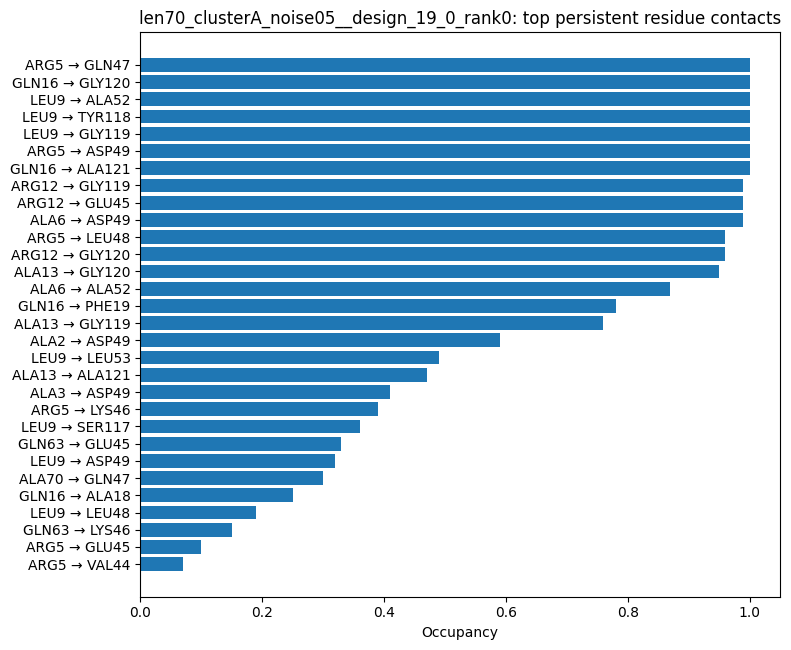


=== Contact persistence: len70_distributed_noise0__design_17_0_rank1 ===


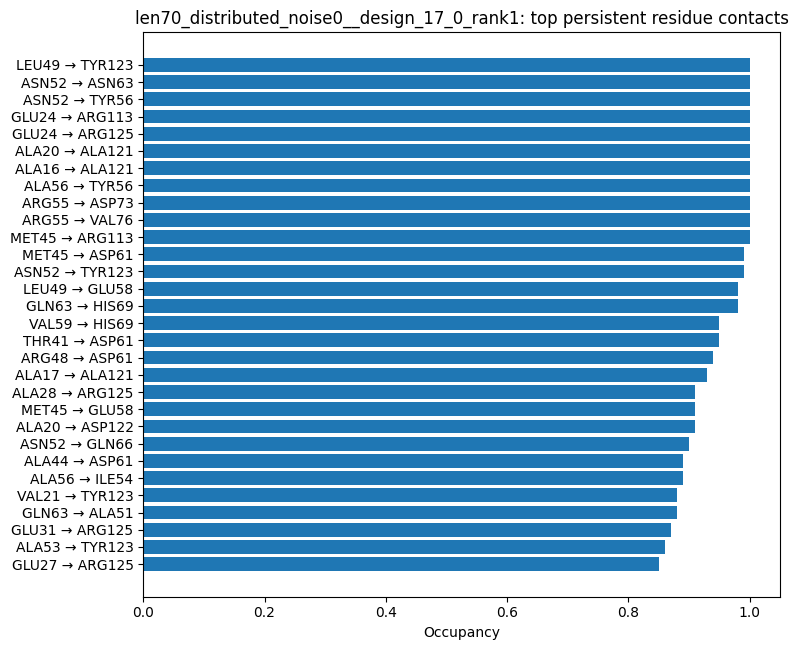


=== Contact persistence: len70_clusterB_noise0__design_19_0_rank1 ===


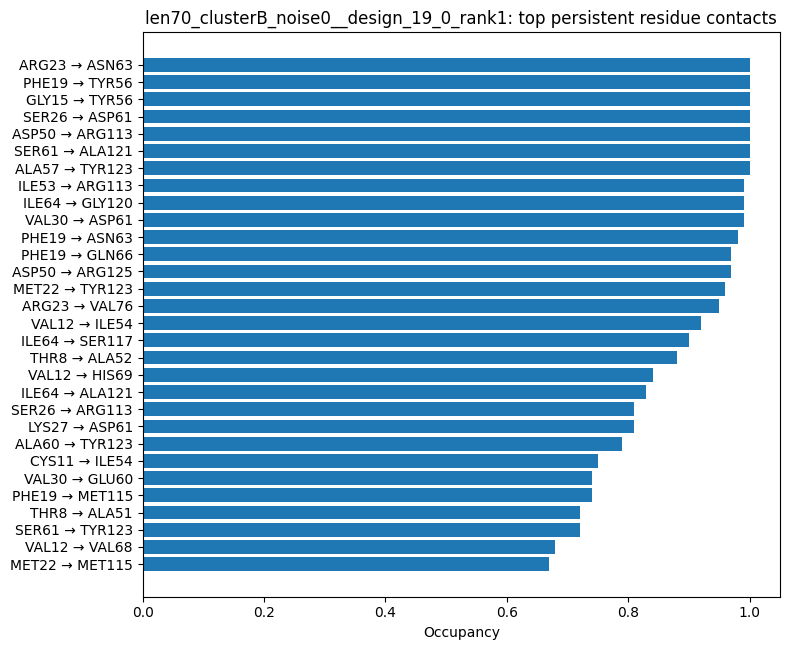

,design_name,n_contacting_pairs,n_pairs_occupancy_ge_0p25,n_pairs_occupancy_ge_0p50,top_pair,top_pair_occupancy,csv,plot
0,len70_clusterA_noise05__design_19_0_rank0,38,26,17,ARG5--GLN47,1.0,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,len70_distributed_noise0__design_17_0_rank1,71,46,41,LEU49--TYR123,1.0,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,len70_clusterB_noise0__design_19_0_rank1,75,38,32,ARG23--ASN63,1.0,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...


In [4]:
# ============================================================
# Cell 3 — Residue-pair contact persistence
# ============================================================

def compute_contact_persistence(system_info, contact_cutoff_nm=CONTACT_CUTOFF_NM, force=FORCE_CORE_ANALYSIS):
    out_dir = system_outdir(system_info)
    out_csv = out_dir / "core_interface_pair_persistence.csv"
    out_json = out_dir / "core_interface_pair_persistence_summary.json"
    out_png = out_dir / "core_top_contact_occupancies.png"

    if out_csv.exists() and out_json.exists() and not force:
        with open(out_json) as f:
            summary = json.load(f)
        return pd.read_csv(out_csv), summary

    design = system_info.get("design_name")
    print(f"\n=== Contact persistence: {design} ===")
    traj, target_chain_idx, binder_chain_idx = load_protein_trajectory(system_info)
    frame_interval_ps = infer_frame_interval_ps(traj, system_info)

    target_residues = [r for r in traj.topology.residues if r.chain.index == target_chain_idx and r.is_protein]
    binder_residues = [r for r in traj.topology.residues if r.chain.index == binder_chain_idx and r.is_protein]

    rows = []
    for b_res in binder_residues:
        b_atoms = [a.index for a in b_res.atoms if a.element.symbol != "H"]
        if not b_atoms:
            continue
        for t_res in target_residues:
            t_atoms = [a.index for a in t_res.atoms if a.element.symbol != "H"]
            if not t_atoms:
                continue
            atom_pairs = np.array([(i, j) for i in b_atoms for j in t_atoms], dtype=int)
            d = md.compute_distances(traj, atom_pairs)
            min_d = d.min(axis=1)
            in_contact = min_d < contact_cutoff_nm
            occ = float(np.mean(in_contact))
            if occ <= 0:
                continue
            runs = contiguous_true_runs(in_contact)
            rows.append({
                "design_name": design,
                "condition_id": system_info.get("condition_id"),
                "binder_residue": residue_label(b_res),
                "binder_resname": b_res.name,
                "binder_resseq": b_res.resSeq,
                "target_residue": residue_label(t_res),
                "target_resname": t_res.name,
                "target_resseq": t_res.resSeq,
                "interaction_class_candidate": classify_pair(b_res.name, t_res.name),
                "occupancy": occ,
                "n_contact_frames": int(in_contact.sum()),
                "n_transitions_on": transition_count_on(in_contact),
                "mean_residence_ps": float(np.mean(runs) * frame_interval_ps) if runs and np.isfinite(frame_interval_ps) else np.nan,
                "max_residence_ps": float(np.max(runs) * frame_interval_ps) if runs and np.isfinite(frame_interval_ps) else np.nan,
                "min_distance_mean_A": float(np.mean(min_d) * 10.0),
                "min_distance_min_A": float(np.min(min_d) * 10.0),
            })

    df = pd.DataFrame(rows).sort_values("occupancy", ascending=False) if rows else pd.DataFrame()
    df.to_csv(out_csv, index=False)

    summary = {
        "design_name": design,
        "n_contacting_pairs": int(len(df)),
        "n_pairs_occupancy_ge_0p25": int((df["occupancy"] >= 0.25).sum()) if len(df) else 0,
        "n_pairs_occupancy_ge_0p50": int((df["occupancy"] >= 0.50).sum()) if len(df) else 0,
        "top_pair": None if len(df) == 0 else f"{df.iloc[0]['binder_residue']}--{df.iloc[0]['target_residue']}",
        "top_pair_occupancy": None if len(df) == 0 else float(df.iloc[0]["occupancy"]),
        "csv": str(out_csv),
        "plot": str(out_png),
    }
    with open(out_json, "w") as f:
        json.dump(summary, f, indent=2)

    if len(df):
        top = df.head(TOP_N_CONTACTS).copy()
        top["pair"] = top["binder_residue"] + " → " + top["target_residue"]
        fig, ax = plt.subplots(figsize=(8, max(4, 0.22 * len(top))))
        ax.barh(top["pair"][::-1], top["occupancy"][::-1])
        ax.set_xlabel("Occupancy")
        ax.set_title(f"{design}: top persistent residue contacts")
        fig.tight_layout()
        fig.savefig(out_png, dpi=200)
        plt.show()

    return df, summary

contact_summaries = []
contact_tables = {}
for s in completed_systems:
    df, summary = compute_contact_persistence(s)
    s["core_contacts"] = summary
    contact_tables[s.get("design_name")] = df
    contact_summaries.append(summary)

df_contact_summary = pd.DataFrame(contact_summaries)
display(df_contact_summary)


## Cell 4 — Interface hydrogen-bond occupancy

This adds geometric validation for polar contacts. Treat these as detected H-bond geometries, not energetic proof.


=== Interface H-bonds: len70_clusterA_noise05__design_19_0_rank0 ===


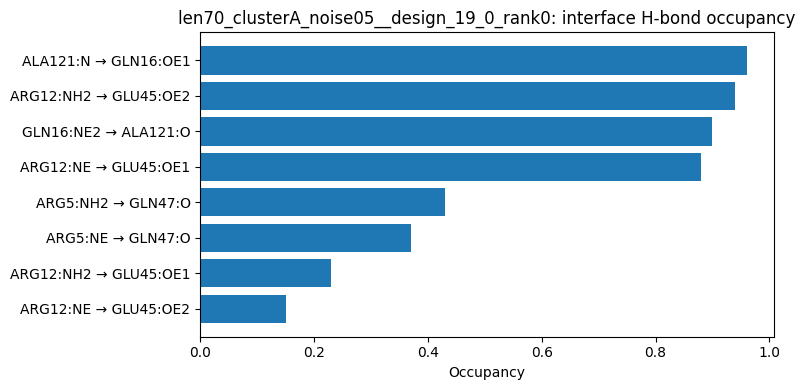


=== Interface H-bonds: len70_distributed_noise0__design_17_0_rank1 ===


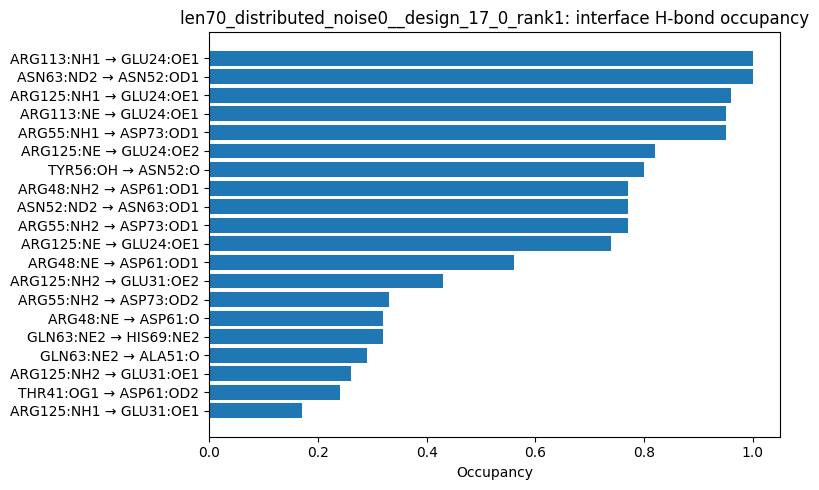


=== Interface H-bonds: len70_clusterB_noise0__design_19_0_rank1 ===


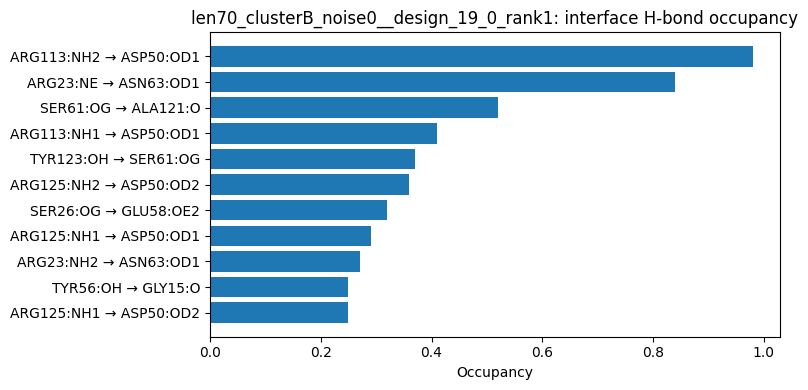

,design_name,n_interface_hbonds_ge_threshold,max_hbond_occupancy,csv,plot
0,len70_clusterA_noise05__design_19_0_rank0,8,0.96,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,len70_distributed_noise0__design_17_0_rank1,21,1.00,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,len70_clusterB_noise0__design_19_0_rank1,12,0.98,/content/drive/Othercomputers/My Mac/pdl1-mini...,/content/drive/Othercomputers/My Mac/pdl1-mini...


In [5]:
# ============================================================
# Cell 4 — Interface hydrogen-bond occupancy
# ============================================================

def compute_interface_hbonds(system_info, min_occupancy=HBOND_MIN_OCCUPANCY, force=FORCE_CORE_ANALYSIS):
    out_dir = system_outdir(system_info)
    out_csv = out_dir / "core_interface_hbonds.csv"
    out_json = out_dir / "core_interface_hbonds_summary.json"
    out_png = out_dir / "core_interface_hbonds.png"

    if out_csv.exists() and out_json.exists() and not force:
        with open(out_json) as f:
            return pd.read_csv(out_csv), json.load(f)

    design = system_info.get("design_name")
    print(f"\n=== Interface H-bonds: {design} ===")
    traj, target_chain_idx, binder_chain_idx = load_protein_trajectory(system_info)
    frame_interval_ps = infer_frame_interval_ps(traj, system_info)

    hbonds = md.baker_hubbard(traj, periodic=True, freq=0.0)
    rows = []
    for donor_idx, hydrogen_idx, acceptor_idx in hbonds:
        donor = traj.topology.atom(donor_idx)
        hydrogen = traj.topology.atom(hydrogen_idx)
        acceptor = traj.topology.atom(acceptor_idx)
        donor_chain = donor.residue.chain.index
        acceptor_chain = acceptor.residue.chain.index
        crosses_interface = {donor_chain, acceptor_chain} == {target_chain_idx, binder_chain_idx}
        if not crosses_interface:
            continue

        # Baker-Hubbard criteria approximated per-frame: H-A < 0.25 nm and D-H-A angle > 120°.
        ha = md.compute_distances(traj, np.array([[hydrogen_idx, acceptor_idx]], dtype=int))[:, 0]
        angles = md.compute_angles(traj, np.array([[donor_idx, hydrogen_idx, acceptor_idx]], dtype=int))[:, 0]
        present = (ha < 0.25) & (angles > np.deg2rad(120))
        occ = float(np.mean(present))
        if occ < min_occupancy:
            continue
        rows.append({
            "design_name": design,
            "donor_residue": residue_label(donor.residue),
            "donor_atom": donor.name,
            "acceptor_residue": residue_label(acceptor.residue),
            "acceptor_atom": acceptor.name,
            "donor_chain_role": "binder" if donor_chain == binder_chain_idx else "target",
            "acceptor_chain_role": "binder" if acceptor_chain == binder_chain_idx else "target",
            "occupancy": occ,
            "mean_HA_distance_A": float(np.mean(ha[present]) * 10.0) if present.any() else np.nan,
            "mean_DHA_angle_deg": float(np.mean(np.rad2deg(angles[present]))) if present.any() else np.nan,
            "max_residence_ps": float(max(contiguous_true_runs(present)) * frame_interval_ps) if present.any() and np.isfinite(frame_interval_ps) else np.nan,
        })

    df = pd.DataFrame(rows).sort_values("occupancy", ascending=False) if rows else pd.DataFrame()
    df.to_csv(out_csv, index=False)
    summary = {
        "design_name": design,
        "n_interface_hbonds_ge_threshold": int(len(df)),
        "max_hbond_occupancy": float(df["occupancy"].max()) if len(df) else 0.0,
        "csv": str(out_csv),
        "plot": str(out_png),
    }
    with open(out_json, "w") as f:
        json.dump(summary, f, indent=2)

    if len(df):
        plot_df = df.head(20).copy()
        plot_df["hbond"] = plot_df["donor_residue"] + ":" + plot_df["donor_atom"] + " → " + plot_df["acceptor_residue"] + ":" + plot_df["acceptor_atom"]
        fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(plot_df))))
        ax.barh(plot_df["hbond"][::-1], plot_df["occupancy"][::-1])
        ax.set_xlabel("Occupancy")
        ax.set_title(f"{design}: interface H-bond occupancy")
        fig.tight_layout()
        fig.savefig(out_png, dpi=200)
        plt.show()

    return df, summary

hbond_summaries = []
hbond_tables = {}
for s in completed_systems:
    df, summary = compute_interface_hbonds(s)
    s["core_hbonds"] = summary
    hbond_tables[s.get("design_name")] = df
    hbond_summaries.append(summary)

df_hbond_summary = pd.DataFrame(hbond_summaries)
display(df_hbond_summary)


## Cell 5 — Salt bridge and cation-π geometric screening

This validates candidate electrostatic/aromatic interactions using simple distance geometry. Histidine/protonation and aromatic orientation are approximations.

In [6]:
# ============================================================
# Cell 5 — Salt bridge and cation-pi geometric screening
# ============================================================

def residue_atoms_by_name(residue, allowed_names):
    return [a.index for a in residue.atoms if a.name in allowed_names]


def compute_geometric_interactions(system_info, force=FORCE_CORE_ANALYSIS):
    out_dir = system_outdir(system_info)
    out_csv = out_dir / "core_saltbridge_cationpi_geometry.csv"
    out_json = out_dir / "core_saltbridge_cationpi_summary.json"

    if out_csv.exists() and out_json.exists() and not force:
        with open(out_json) as f:
            return pd.read_csv(out_csv), json.load(f)

    design = system_info.get("design_name")
    print(f"\n=== Salt bridge / cation-pi geometry: {design} ===")
    traj, target_chain_idx, binder_chain_idx = load_protein_trajectory(system_info)
    frame_interval_ps = infer_frame_interval_ps(traj, system_info)

    target_residues = [r for r in traj.topology.residues if r.chain.index == target_chain_idx and r.is_protein]
    binder_residues = [r for r in traj.topology.residues if r.chain.index == binder_chain_idx and r.is_protein]
    rows = []

    # Salt bridges: min charged atom distance < 4.0 Å.
    charged_binder = [r for r in binder_residues if r.name in CHARGED_ATOMS]
    charged_target = [r for r in target_residues if r.name in CHARGED_ATOMS]
    for b in charged_binder:
        for t in charged_target:
            opposite = ((b.name in AA_CLASSES["positive"] and t.name in AA_CLASSES["negative"]) or
                        (b.name in AA_CLASSES["negative"] and t.name in AA_CLASSES["positive"]))
            if not opposite:
                continue
            b_atoms = residue_atoms_by_name(b, CHARGED_ATOMS[b.name])
            t_atoms = residue_atoms_by_name(t, CHARGED_ATOMS[t.name])
            if not b_atoms or not t_atoms:
                continue
            pairs = np.array([(i, j) for i in b_atoms for j in t_atoms], dtype=int)
            d = md.compute_distances(traj, pairs).min(axis=1)
            present = d < 0.40
            occ = float(np.mean(present))
            if occ <= 0:
                continue
            rows.append({
                "design_name": design,
                "interaction_type": "salt_bridge_geometry",
                "binder_residue": residue_label(b),
                "target_residue": residue_label(t),
                "occupancy": occ,
                "mean_distance_A_when_present": float(np.mean(d[present]) * 10.0) if present.any() else np.nan,
                "min_distance_A": float(np.min(d) * 10.0),
                "max_residence_ps": float(max(contiguous_true_runs(present)) * frame_interval_ps) if present.any() and np.isfinite(frame_interval_ps) else np.nan,
            })

    # Cation-pi: cation charged atom to aromatic ring centroid < 6.0 Å. Orientation not evaluated.
    def ring_centroid_xyz(residue):
        atoms = residue_atoms_by_name(residue, AROMATIC_RING_ATOMS.get(residue.name, []))
        if len(atoms) < 4:
            return None
        return traj.xyz[:, atoms, :].mean(axis=1)

    positive_binder = [r for r in binder_residues if r.name in AA_CLASSES["positive"]]
    positive_target = [r for r in target_residues if r.name in AA_CLASSES["positive"]]
    aromatic_binder = [r for r in binder_residues if r.name in AROMATIC_RING_ATOMS]
    aromatic_target = [r for r in target_residues if r.name in AROMATIC_RING_ATOMS]

    cation_pi_pairs = []
    cation_pi_pairs += [("binder_cation_target_pi", c, a) for c in positive_binder for a in aromatic_target]
    cation_pi_pairs += [("target_cation_binder_pi", c, a) for c in positive_target for a in aromatic_binder]

    for label, cation_res, aromatic_res in cation_pi_pairs:
        c_atoms = residue_atoms_by_name(cation_res, CHARGED_ATOMS.get(cation_res.name, []))
        centroid = ring_centroid_xyz(aromatic_res)
        if not c_atoms or centroid is None:
            continue
        c_xyz = traj.xyz[:, c_atoms, :].mean(axis=1)
        d = np.linalg.norm(c_xyz - centroid, axis=1)
        present = d < 0.60
        occ = float(np.mean(present))
        if occ <= 0:
            continue
        b_res = cation_res if cation_res.chain.index == binder_chain_idx else aromatic_res
        t_res = aromatic_res if aromatic_res.chain.index == target_chain_idx else cation_res
        rows.append({
            "design_name": design,
            "interaction_type": f"cation_pi_geometry_{label}",
            "binder_residue": residue_label(b_res),
            "target_residue": residue_label(t_res),
            "occupancy": occ,
            "mean_distance_A_when_present": float(np.mean(d[present]) * 10.0) if present.any() else np.nan,
            "min_distance_A": float(np.min(d) * 10.0),
            "max_residence_ps": float(max(contiguous_true_runs(present)) * frame_interval_ps) if present.any() and np.isfinite(frame_interval_ps) else np.nan,
        })

    df = pd.DataFrame(rows).sort_values(["interaction_type", "occupancy"], ascending=[True, False]) if rows else pd.DataFrame()
    df.to_csv(out_csv, index=False)
    summary = {
        "design_name": design,
        "n_geometric_salt_bridges": int((df["interaction_type"] == "salt_bridge_geometry").sum()) if len(df) else 0,
        "n_geometric_cation_pi": int(df["interaction_type"].str.contains("cation_pi").sum()) if len(df) else 0,
        "max_geometry_occupancy": float(df["occupancy"].max()) if len(df) else 0.0,
        "csv": str(out_csv),
    }
    with open(out_json, "w") as f:
        json.dump(summary, f, indent=2)
    return df, summary

geometry_summaries = []
geometry_tables = {}
for s in completed_systems:
    df, summary = compute_geometric_interactions(s)
    s["core_geometry"] = summary
    geometry_tables[s.get("design_name")] = df
    geometry_summaries.append(summary)

df_geometry_summary = pd.DataFrame(geometry_summaries)
display(df_geometry_summary)



=== Salt bridge / cation-pi geometry: len70_clusterA_noise05__design_19_0_rank0 ===

=== Salt bridge / cation-pi geometry: len70_distributed_noise0__design_17_0_rank1 ===

=== Salt bridge / cation-pi geometry: len70_clusterB_noise0__design_19_0_rank1 ===


,design_name,n_geometric_salt_bridges,n_geometric_cation_pi,max_geometry_occupancy,csv
0,len70_clusterA_noise05__design_19_0_rank0,3,0,0.98,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,len70_distributed_noise0__design_17_0_rank1,6,0,1.00,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,len70_clusterB_noise0__design_19_0_rank1,4,0,0.99,/content/drive/Othercomputers/My Mac/pdl1-mini...


## Cell 6 — Hotspot recapitulation: optional, but high-value

Fill in the actual PD-L1 hotspot residues used in RFdiffusion. This cell intentionally does **not** hardcode guesses. If no hotspot map is supplied, it will skip scoring rather than produce fake confidence.

In [7]:
# ============================================================
# Cell 6 — Hotspot recapitulation, using user-supplied target residues
# ============================================================

# Fill these from your actual RFdiffusion configs.
# Accepted formats are residue numbers as integers or strings, e.g. [56, 115, 123].
# Keys are matched against condition_id substrings.
HOTSPOT_TARGET_RESIDUES_BY_CONDITION_SUBSTRING = {
    # From conditions.csv hotspot_residues column.
    # Target chain prefix A is omitted here because the scoring function
    # compares residue numbers on the target chain already.
    "clusterA": [18, 20, 122],
    "clusterB": [26, 56, 113, 123, 125],
    "distributed": [18, 20, 26, 56, 113, 120, 122, 125],
}


def hotspot_list_for_system(system_info):
    condition_id = str(system_info.get("condition_id", ""))
    for key, residues in HOTSPOT_TARGET_RESIDUES_BY_CONDITION_SUBSTRING.items():
        if key in condition_id:
            return {int(r) for r in residues}
    return set()


def score_hotspot_recapitulation(system_info, contact_df, force=FORCE_CORE_ANALYSIS):
    out_dir = system_outdir(system_info)
    out_csv = out_dir / "core_hotspot_recapitulation.csv"
    out_json = out_dir / "core_hotspot_recapitulation_summary.json"

    hotspots = hotspot_list_for_system(system_info)
    design = system_info.get("design_name")
    if not hotspots:
        summary = {
            "design_name": design,
            "status": "skipped_no_hotspot_map_supplied",
            "n_hotspots_configured": 0,
            "n_hotspots_contacted": 0,
            "hotspot_recall": np.nan,
            "csv": str(out_csv),
        }
        with open(out_json, "w") as f:
            json.dump(summary, f, indent=2)
        pd.DataFrame().to_csv(out_csv, index=False)
        return pd.DataFrame(), summary

    if contact_df is None or len(contact_df) == 0:
        contacted = set()
        rows = []
    else:
        contact_df = contact_df.copy()
        contact_df["target_resseq_int"] = contact_df["target_resseq"].astype(int)
        rows = []
        for h in sorted(hotspots):
            sub = contact_df[contact_df["target_resseq_int"] == h].sort_values("occupancy", ascending=False)
            rows.append({
                "design_name": design,
                "target_hotspot_resseq": h,
                "contacted_in_md": bool(len(sub) > 0),
                "max_contact_occupancy": float(sub["occupancy"].max()) if len(sub) else 0.0,
                "top_binder_contact": sub.iloc[0]["binder_residue"] if len(sub) else None,
                "top_target_contact": sub.iloc[0]["target_residue"] if len(sub) else None,
            })
        contacted = {r["target_hotspot_resseq"] for r in rows if r["contacted_in_md"]}

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    summary = {
        "design_name": design,
        "status": "scored",
        "n_hotspots_configured": int(len(hotspots)),
        "n_hotspots_contacted": int(len(contacted)),
        "hotspot_recall": float(len(contacted) / len(hotspots)) if hotspots else np.nan,
        "csv": str(out_csv),
    }
    with open(out_json, "w") as f:
        json.dump(summary, f, indent=2)
    return df, summary

hotspot_summaries = []
hotspot_tables = {}
for s in completed_systems:
    design = s.get("design_name")
    df, summary = score_hotspot_recapitulation(s, contact_tables.get(design))
    s["core_hotspots"] = summary
    hotspot_tables[design] = df
    hotspot_summaries.append(summary)

df_hotspot_summary = pd.DataFrame(hotspot_summaries)
display(df_hotspot_summary)


,design_name,status,n_hotspots_configured,n_hotspots_contacted,hotspot_recall,csv
0,len70_clusterA_noise05__design_19_0_rank0,scored,3,2,0.666667,/content/drive/Othercomputers/My Mac/pdl1-mini...
1,len70_distributed_noise0__design_17_0_rank1,scored,8,5,0.625000,/content/drive/Othercomputers/My Mac/pdl1-mini...
2,len70_clusterB_noise0__design_19_0_rank1,scored,5,4,0.800000,/content/drive/Othercomputers/My Mac/pdl1-mini...


## Cell 7 — Consolidated core-extension summary

This table is the one to use for portfolio-facing interpretation. It deliberately avoids affinity-like metrics.

Saved: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_extensions_core_summary.csv


,design_name,condition_id,candidate_class,production_ns,interface_rmsd_mean_A,interface_rmsd_final_A,com_drift_final_A,n_contacting_pairs,n_pairs_occupancy_ge_0p25,n_pairs_occupancy_ge_0p50,top_pair,top_pair_occupancy,n_interface_hbonds_ge_0p10,max_hbond_occupancy,n_geometric_salt_bridges,n_geometric_cation_pi,hotspot_status,hotspot_recall
0,len70_clusterA_noise05__design_19_0_rank0,len70_clusterA_noise05,sequence_threaded_complex,1,111.291985,125.490509,-67.391006,38,26,17,ARG5--GLN47,1.0,8,0.96,3,0,scored,0.666667
1,len70_distributed_noise0__design_17_0_rank1,len70_distributed_noise0,sequence_threaded_complex,1,84.462830,25.743582,0.791687,71,46,41,LEU49--TYR123,1.0,21,1.00,6,0,scored,0.625000
2,len70_clusterB_noise0__design_19_0_rank1,len70_clusterB_noise0,sequence_threaded_complex,1,92.807022,108.458824,-48.858147,75,38,32,ARG23--ASN63,1.0,12,0.98,4,0,scored,0.800000


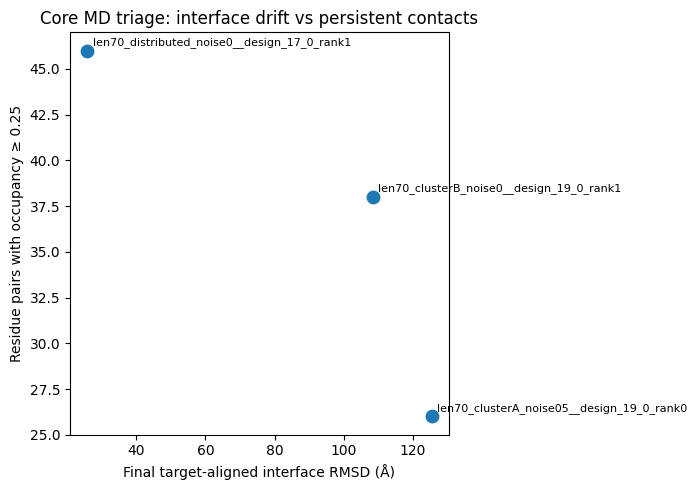

Saved plot: /content/drive/Othercomputers/My Mac/pdl1-mini-binder-design/data/results/md_simulations_threaded_complexes/md_extensions_core_triage_scatter.png


In [8]:
# ============================================================
# Cell 7 — Consolidated core extension summary
# ============================================================

rows = []
for s in completed_systems:
    design = s.get("design_name")
    interface = s.get("core_interface", {})
    contacts = s.get("core_contacts", {})
    hbonds = s.get("core_hbonds", {})
    geom = s.get("core_geometry", {})
    hotspots = s.get("core_hotspots", {})

    rows.append({
        "design_name": design,
        "condition_id": s.get("condition_id"),
        "candidate_class": s.get("candidate_class"),
        "production_ns": s.get("production_ns"),
        "interface_rmsd_mean_A": interface.get("interface_rmsd_mean_A"),
        "interface_rmsd_final_A": interface.get("interface_rmsd_final_A"),
        "com_drift_final_A": interface.get("com_drift_final_A"),
        "n_contacting_pairs": contacts.get("n_contacting_pairs"),
        "n_pairs_occupancy_ge_0p25": contacts.get("n_pairs_occupancy_ge_0p25"),
        "n_pairs_occupancy_ge_0p50": contacts.get("n_pairs_occupancy_ge_0p50"),
        "top_pair": contacts.get("top_pair"),
        "top_pair_occupancy": contacts.get("top_pair_occupancy"),
        "n_interface_hbonds_ge_0p10": hbonds.get("n_interface_hbonds_ge_threshold"),
        "max_hbond_occupancy": hbonds.get("max_hbond_occupancy"),
        "n_geometric_salt_bridges": geom.get("n_geometric_salt_bridges"),
        "n_geometric_cation_pi": geom.get("n_geometric_cation_pi"),
        "hotspot_status": hotspots.get("status"),
        "hotspot_recall": hotspots.get("hotspot_recall"),
    })

df_core_summary = pd.DataFrame(rows)
df_core_summary.to_csv(CORE_SUMMARY_PATH, index=False)
print("Saved:", CORE_SUMMARY_PATH)
display(df_core_summary)

# A simple failure-detection plot. Lower RMSD/drift and more persistent contacts are generally better for triage.
if len(df_core_summary):
    fig, ax = plt.subplots(figsize=(7, 5))
    x = df_core_summary["interface_rmsd_final_A"].astype(float)
    y = df_core_summary["n_pairs_occupancy_ge_0p25"].astype(float)
    ax.scatter(x, y, s=80)
    for _, r in df_core_summary.iterrows():
        ax.annotate(str(r["design_name"]), (r["interface_rmsd_final_A"], r["n_pairs_occupancy_ge_0p25"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Final target-aligned interface RMSD (Å)")
    ax.set_ylabel("Residue pairs with occupancy ≥ 0.25")
    ax.set_title("Core MD triage: interface drift vs persistent contacts")
    fig.tight_layout()
    out_png = MD_OUTPUT_DIR / "md_extensions_core_triage_scatter.png"
    fig.savefig(out_png, dpi=200)
    plt.show()
    print("Saved plot:", out_png)


## Interpretation guardrail

Use this notebook as a failure-detection layer. These analyses can justify deprioritizing designs that drift, detach, or lose their intended interface. They should not be presented as evidence of binding affinity, successful binder design, or experimental validation.